<a href="https://colab.research.google.com/github/Maria-Zourob/Machine-Learning-Exam/blob/main/Maria_Zourob_2320257099_ML_MidExam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Project: Medical Cost Prediction
**Prepared by:** Maria Anwar Zourob  
**Student ID:** [2320257099]

## 1. Import Libraries
In this section, we import all the necessary libraries required for data manipulation, visualization, and building the machine learning model.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

## 2. Data Preprocessing & Cleaning
We load the medical cost dataset, check for any missing values, and handle duplicate records to ensure the data is clean before analysis.

In [9]:
df = pd.read_csv('insurance.csv')


print("--- Missing Values Per Column ---")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed successfully!")

--- Missing Values Per Column ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Number of duplicate rows: 1
Duplicate rows removed successfully!


## 3. Exploratory Data Analysis (EDA)
Here, we visualize the distribution of medical charges and explore the relationship between the target variable and categorical features like smoking status.

/tmp/ipykernel_1531/3554793065.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')


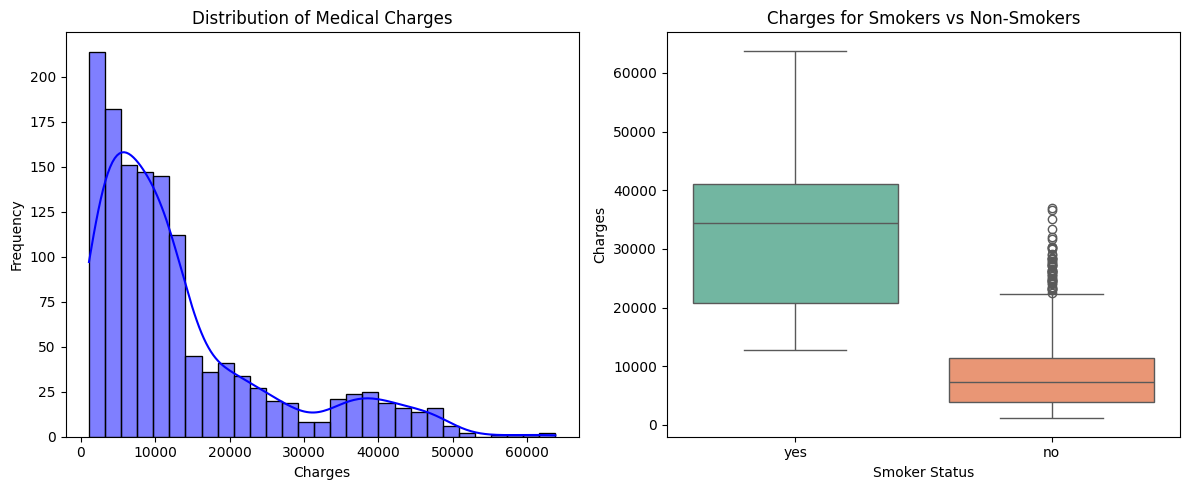

In [10]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['charges'], kde=True, color='blue')
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title('Charges for Smokers vs Non-Smokers')
plt.xlabel('Smoker Status')
plt.ylabel('Charges')

plt.tight_layout()
plt.show()

## 4. Feature Engineering & Data Splitting
In this step, we separate the features ($X$) from the target variable ($y$). We then encode the categorical variables using One-Hot Encoding and scale the numerical variables using StandardScaler. Finally, we split the dataset into 80% training and 20% testing sets.

In [11]:

X = df.drop(columns=['charges'])
y = df['charges']

numerical_cols = ['age', 'bmi', 'children']
categorical_cols = ['sex', 'smoker', 'region']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print("--- Data Splitting Shapes ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

--- Data Splitting Shapes ---
X_train shape: (1069, 8)
X_test shape: (268, 8)
y_train shape: (1069,)
y_test shape: (268,)


## 5. Model Training, Regularization & Evaluation
We implement a Baseline Linear Regression model and compare it with a regularized model (Ridge Regression). We use 5-Fold Cross-Validation to ensure stability and evaluate performance using $R^2$ score and Root Mean Squared Error (RMSE).

In [12]:

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)


y_pred_baseline = baseline_model.predict(X_test)
r2_baseline = r2_score(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(ridge_model, X_processed, y, cv=kf, scoring='r2')

print("--- Baseline Linear Regression Results ---")
print(f"R² Score: {r2_baseline:.4f}")
print(f"RMSE: {rmse_baseline:.2f}")

print("\n--- Regularized Ridge Regression (alpha=1.0) Results ---")
print(f"R² Score: {r2_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.2f}")

print("\n--- 5-Fold Cross-Validation (Ridge R² Scores) ---")
print(f"Scores per fold: {cv_scores}")
print(f"Mean CV R² Score: {cv_scores.mean():.4f}")

--- Baseline Linear Regression Results ---
R² Score: 0.8069
RMSE: 5956.34

--- Regularized Ridge Regression (alpha=1.0) Results ---
R² Score: 0.8059
RMSE: 5971.87

--- 5-Fold Cross-Validation (Ridge R² Scores) ---
Scores per fold: [0.80592101 0.71392113 0.75200407 0.67551335 0.74842274]
Mean CV R² Score: 0.7392


### **Alpha Choice Justification:**
We selected $\alpha = 1.0$ for the Ridge regression because it provides a baseline penalty that shrinks the coefficients of less important features without underfitting the model, maintaining a stable $R^2$ score of approximately 74% across all folds during cross-validation.